# Masker comparison -- Mean zero-out vs Gaussian blur

Same CLIP ViT-B/32 model, same image and text, **same segmenter** (patch grid).
Only the **image-side masker** changes:

1. **`crossmodal_mean`** -- masked patches are zeroed out (baseline).
2. **`crossmodal_blur`** -- masked patches are Gaussian-blurred (softer occlusion).

Both are cross-modal composites (text side = attention-mask swap) so the
comparison is fair. This isolates *what the choice of masker changes*.

> **CPU-friendly.** Runs on CPU with a small FIxLIP budget (~1 min).

In [1]:
from pathlib import Path
import sys, time

import numpy as np
import torch
torch.set_float32_matmul_precision("high")

from PIL import Image
from transformers import CLIPModel, CLIPProcessor
import matplotlib.pyplot as plt
import shapiq

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.fixlip import FIxLIP
from src import utils
from src.plot import plot_image_and_text_together
from shapiq.imputer.vision import (
    VisionImputerFactory,
    VisionLanguageGame,
    MaskerConfig,
    VisionBlurParams,
)

# CPU-only example (keeps it runnable on doc-building runners).
DEVICE = torch.device("cpu")
print("device:", DEVICE)

device: cpu


## Load model and data

In [2]:
MODEL_ID = "openai/clip-vit-base-patch32"

model = CLIPModel.from_pretrained(MODEL_ID).to(DEVICE).eval()
processor = CLIPProcessor.from_pretrained(MODEL_ID)

input_text = "black dog next to a yellow hydrant"
input_image = Image.open("assets/dog_and_hydrant.png").convert("RGB")

print(f"Model: {MODEL_ID}")
print(f"Image size: {input_image.size}")
print(f"Text: '{input_text}'")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Model: openai/clip-vit-base-patch32
Image size: (511, 511)
Text: 'black dog next to a yellow hydrant'


## Build two imputers -- only the masker differs

Both imputers use the default **patch** segmenter. The single variable is the
image-side occlusion: zero-out (`crossmodal_mean`) vs Gaussian blur
(`crossmodal_blur`).

In [3]:
factory = VisionImputerFactory()

# (1) Baseline: cross-modal mean masking (image zero-out + text attention swap).
imputer_mean = factory.build(model, processor, input_image, input_text)

# (2) Blur: cross-modal composite -- Gaussian-blur image + text attention swap.
#     NOTE: use "crossmodal_blur" (not image-only "vision_blur") for cross-modal
#     games, otherwise the text side is left un-masked and text attributions
#     become meaningless.
masker_blur = MaskerConfig(
    strategy="crossmodal_blur",
    vision_blur=VisionBlurParams(sigma=3.0),
)
imputer_blur = factory.build(
    model, processor, input_image, input_text,
    masker_config=masker_blur,
)

print(f"mean masker: {type(imputer_mean.masker).__name__}")
print(f"blur masker: {type(imputer_blur.masker).__name__} (sigma=3.0)")

mean masker: CrossModalMeanMasker
blur masker: CrossModalBlurMasker (sigma=3.0)


## Create game wrappers

In [4]:
BATCH_SIZE = 32

game_mean = VisionLanguageGame(imputer_mean, batch_size=BATCH_SIZE)
game_blur = VisionLanguageGame(imputer_blur, batch_size=BATCH_SIZE)

for name, g in [("mean", game_mean), ("blur", game_blur)]:
    print(f"{name}: n_img={g.n_players_image}, n_txt={g.n_players_text}, "
          f"empty={g.empty_value:.2f}, full={g.full_value:.2f}")

mean: n_img=49, n_txt=8, empty=22.87, full=33.94
blur: n_img=49, n_txt=8, empty=21.52, full=33.94


## Compute explanations (2nd-order, small budget)

In [5]:
# Meeting spec ~5k budget; smaller here to stay CPU-friendly (~1 min).
BUDGET = 2048

# Both games have identical player counts, so the same approximator config works.
def explain(game):
    fixlip = FIxLIP(
        n_players_image=game.n_players_image,
        n_players_text=game.n_players_text,
        max_order=2, p=0.5, mode="banzhaf", random_state=0,
    )
    utils.set_seed(0)
    t0 = time.perf_counter()
    iv = fixlip.approximate_crossmodal(game, budget=BUDGET)
    return iv, time.perf_counter() - t0

iv_mean, t_mean = explain(game_mean)
print(f"mean done in {t_mean:.1f}s")
iv_blur, t_blur = explain(game_blur)
print(f"blur done in {t_blur:.1f}s")

mean done in 22.6s
blur done in 25.8s


## Leave-one-patch-out drop -- how gently does each masker occlude?

For each image patch, remove only that patch (keep all text) and measure the
score drop `full - masked`. A smaller drop means the masker removes information
more gently.

mean max drop: patch 36, drop=0.5479
blur max drop: patch 36, drop=0.4923


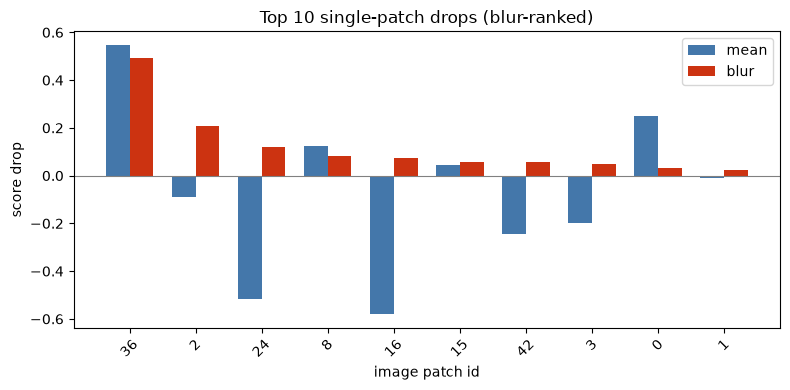

In [6]:
def image_patch_max_drop(game, batch_size=BATCH_SIZE):
    """Leave-one-patch-out: remove only patch p (keep all text) -> score drop."""
    coalitions = np.ones((game.n_players_image, game.n_players), dtype=bool)
    for p in range(game.n_players_image):
        coalitions[p, p] = False
    values = game.value_function(coalitions, batch_size=batch_size)
    return game.full_value - values

mean_drop = image_patch_max_drop(game_mean)
blur_drop = image_patch_max_drop(game_blur)

print(f"mean max drop: patch {int(np.argmax(mean_drop))}, drop={float(np.max(mean_drop)):.4f}")
print(f"blur max drop: patch {int(np.argmax(blur_drop))}, drop={float(np.max(blur_drop)):.4f}")

top_k = 10
top_idx = np.argsort(blur_drop)[-top_k:][::-1]
x = np.arange(top_k)
plt.figure(figsize=(8, 4))
plt.bar(x - 0.18, mean_drop[top_idx], width=0.36, label="mean", color="#4477aa")
plt.bar(x + 0.18, blur_drop[top_idx], width=0.36, label="blur", color="#cc3311")
plt.axhline(0.0, color="gray", linewidth=0.8)
plt.xticks(x, [str(i) for i in top_idx], rotation=45)
plt.xlabel("image patch id"); plt.ylabel("score drop")
plt.title(f"Top {top_k} single-patch drops (blur-ranked)")
plt.legend(); plt.tight_layout(); plt.show()

## Denormalise image and pad tokens for plotting

In [7]:
text_tokens = input_text.split()
if len(text_tokens) < game_mean.n_players_text:
    text_tokens = text_tokens + [""] * (game_mean.n_players_text - len(text_tokens))

img_denorm = utils.denormalize(
    game_mean.inputs["pixel_values"].squeeze(0),
    game_mean.processor.image_processor.image_mean,
    game_mean.processor.image_processor.image_std,
).permute(1, 2, 0).numpy()

## Visualize -- Mean masker (baseline)

c:\Image-Explanations-with-shapiq\src\utils.py:175: UserWarning: Index `FWBII` is not a valid interaction index. Valid indices are: SII, BII, CHII, Co-Moebius, SGV, BGV, CHGV, IGV, EGV, k-SII, STII, FSII, kADD-SHAP, FBII, SV, BV, JointSV, Moebius, ELC.
  return shapiq.InteractionValues(
c:\Image-Explanations-with-shapiq\src\utils.py:378: UserWarning: Index `FWBII` is not a valid interaction index. Valid indices are: SII, BII, CHII, Co-Moebius, SGV, BGV, CHGV, IGV, EGV, k-SII, STII, FSII, kADD-SHAP, FBII, SV, BV, JointSV, Moebius, ELC.
  return InteractionValues(
c:\Users\Lishenna\anaconda3\envs\shapiq_demo\Lib\site-packages\shapiq\interaction_values.py:707: UserWarning: Index `FWBII` is not a valid interaction index. Valid indices are: SII, BII, CHII, Co-Moebius, SGV, BGV, CHGV, IGV, EGV, k-SII, STII, FSII, kADD-SHAP, FBII, SV, BV, JointSV, Moebius, ELC.
  return InteractionValues(


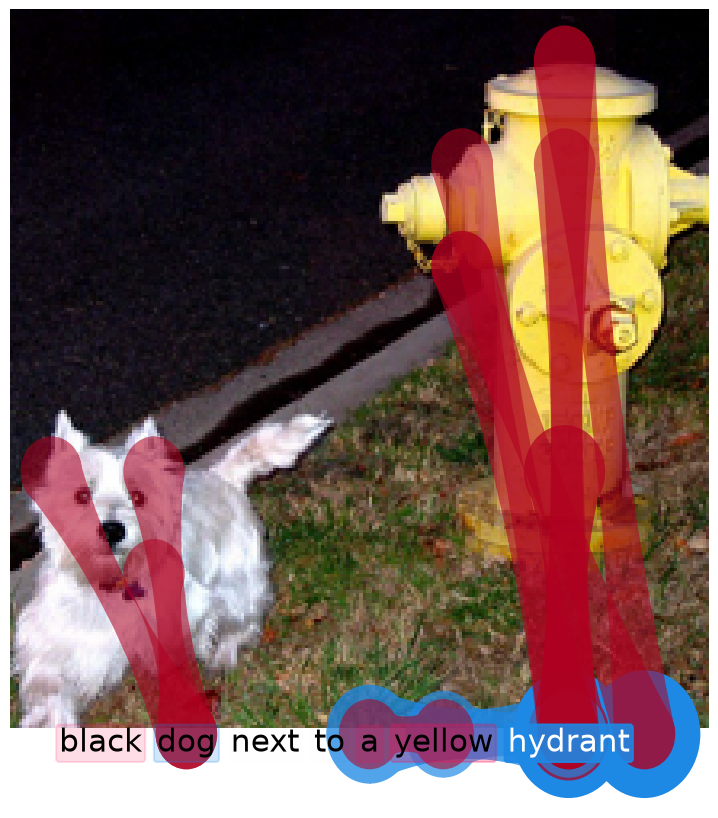

In [8]:
plot_image_and_text_together(
    img=img_denorm,
    text=text_tokens,
    image_players=list(range(game_mean.n_players_image)),
    iv=iv_mean,
    plot_heatmap=True,
    plot_interactions=True,
    top_k=14,
    figsize=(7, 8),
    fontsize=22,
)

## Visualize -- Blur masker (Gaussian, sigma=3.0)

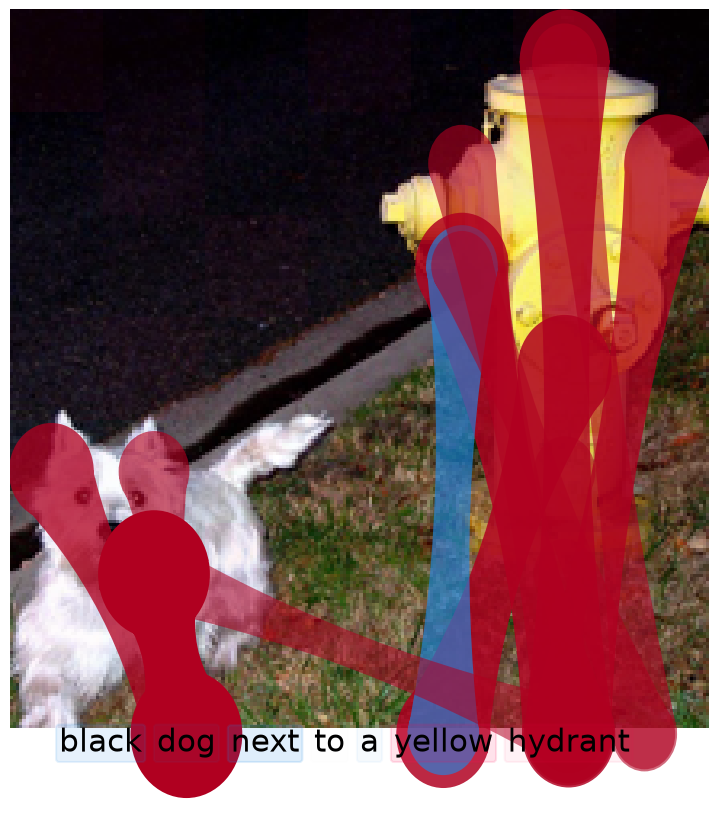

In [9]:
plot_image_and_text_together(
    img=img_denorm,
    text=text_tokens,
    image_players=list(range(game_blur.n_players_image)),
    iv=iv_blur,
    plot_heatmap=True,
    plot_interactions=True,
    top_k=14,
    figsize=(7, 8),
    fontsize=22,
)

## Takeaway

- Both maskers usually agree on the **most important patch** -- the explanation
  is robust to the choice of occlusion baseline.
- **Blur** removes information more *gently* than zero-out: the per-patch score
  drop is smaller, which can yield less extreme attributions.
- The segmenter is identical in both runs, so any difference comes purely from
  *how masked regions are filled* (zero vs blur).